# - Importing data

In [7]:
import pandas as pd
import os
import yfinance as yf
import datetime

os.makedirs("data", exist_ok=True)

start = datetime.datetime(2000, 9, 1)
end = datetime.datetime(2025, 9, 1)


# -----------------------------------------------------------
# GOLD PRICE (GC=F) - Source : Yahoo Finance
# -----------------------------------------------------------

gold = yf.download("GC=F", start=start, end=end, auto_adjust=True, progress=False)
gold = gold[["Close"]].dropna().reset_index()
gold = gold.rename(columns={"Date": "Date", "Close": "Gold"})
gold = gold.sort_values(by="Date")
gold["Date"] = pd.to_datetime(gold["Date"])
gold.to_csv("data/gold_2000_2025.csv", index=False)

print("✅ GOLD data recorded : data/gold_2000_2025.csv")


# -----------------------------------------------------------
# S&P 500 INDEX (^GSPC) - Source : Yahoo Finance
# -----------------------------------------------------------

sp500 = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False)
sp500 = sp500[["Close"]].dropna().reset_index()
sp500 = sp500.rename(columns={"Date": "Date", "Close": "SP500"})
sp500 = sp500.sort_values(by="Date")
sp500["Date"] = pd.to_datetime(sp500["Date"])
sp500.to_csv("data/sp500_2000_2025.csv", index=False)

print("✅ S&P500 data recorded : data/sp500_2000_2025.csv")


# -----------------------------------------------------------
# DOLLAR INDEX (DX-Y.NYB) - Source : Yahoo Finance
# -----------------------------------------------------------

dxy = yf.download("DX-Y.NYB", start=start, end=end, auto_adjust=True, progress=False)
dxy = dxy[["Close"]].dropna().reset_index()
dxy = dxy.rename(columns={"Date": "Date", "Close": "Dollar_Index"})
dxy = dxy.sort_values(by="Date")
dxy["Date"] = pd.to_datetime(dxy["Date"])
dxy.to_csv("data/dollar_index_2000_2025.csv", index=False)

print("✅ Dollar Index data recorded : data/dollar_index_2000_2025.csv")


# -----------------------------------------------------------
# VIX INDEX (^VIX) - Source : Yahoo Finance
# -----------------------------------------------------------

vix = yf.download("^VIX", start=start, end=end, auto_adjust=True, progress=False)
vix = vix[["Close"]].dropna().reset_index()
vix = vix.rename(columns={"Date": "Date", "Close": "VIX"})
vix = vix.sort_values(by="Date")
vix["Date"] = pd.to_datetime(vix["Date"])
vix.to_csv("data/vix_2000_2025.csv", index=False)

print("✅ VIX data recorded : data/vix_2000_2025.csv")


# -----------------------------------------------------------
# US 10-YEAR TREASURY YIELD (^TNX) - Source : Yahoo Finance
# -----------------------------------------------------------

tnx = yf.download("^TNX", start=start, end=end, auto_adjust=True, progress=False)
tnx = tnx[["Close"]].dropna().reset_index()
tnx = tnx.rename(columns={"Date": "Date", "Close": "US10Y"})
tnx = tnx.sort_values(by="Date")
tnx["Date"] = pd.to_datetime(tnx["Date"])
tnx.to_csv("data/us10y_2000_2025.csv", index=False)

print("✅ US 10Y Yield data recorded : data/us10y_2000_2025.csv")

✅ GOLD data recorded : data/gold_2000_2025.csv
✅ S&P500 data recorded : data/sp500_2000_2025.csv
✅ Dollar Index data recorded : data/dollar_index_2000_2025.csv
✅ VIX data recorded : data/vix_2000_2025.csv
✅ US 10Y Yield data recorded : data/us10y_2000_2025.csv


# - Graphical representation

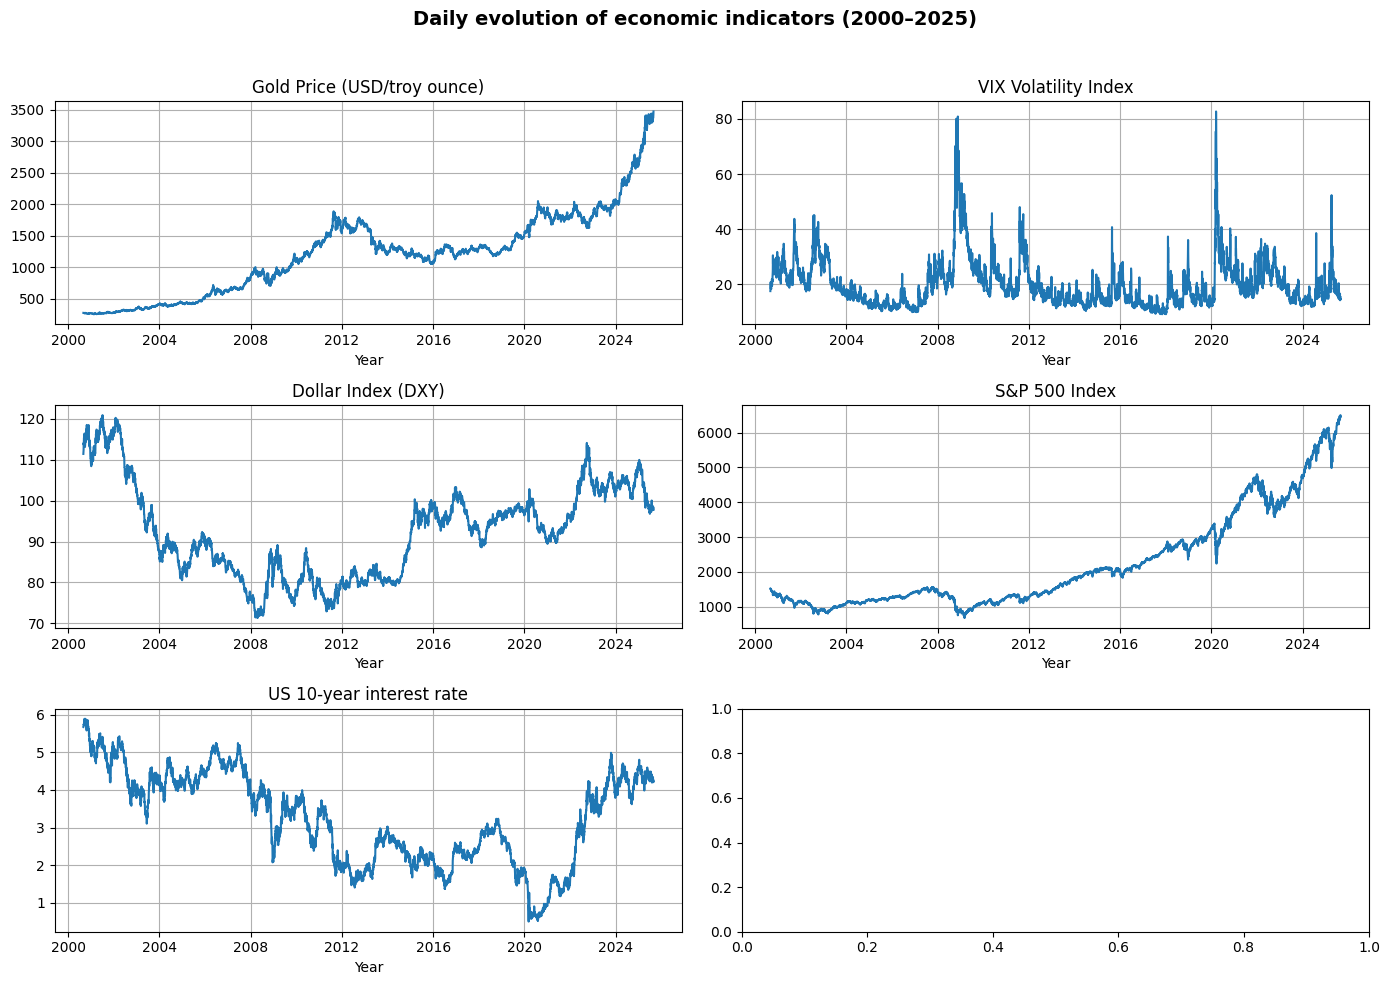

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================
# DATASETS — uniquement les 5 variables du nouveau projet
# ==============================================================

datasets = [
    ("Gold Price (USD/troy ounce)",       "data/gold_2000_2025.csv"),
    ("VIX Volatility Index",              "data/vix_2000_2025.csv"),
    ("Dollar Index (DXY)",                "data/dollar_index_2000_2025.csv"),
    ("S&P 500 Index",                     "data/sp500_2000_2025.csv"),
    ("US 10-year interest rate",          "data/us10y_2000_2025.csv")
]

# ==============================================================
# Fonction générique pour charger / convertir / nettoyer
# ==============================================================

def load_and_prepare(path):
    df = pd.read_csv(path)

    # Harmonisation nom colonne
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    else:
        date_col = df.columns[0]
        df["Date"] = pd.to_datetime(df[date_col], errors="coerce")

    # Détection colonne numérique
    value_cols = [c for c in df.columns if c != "Date"]

    # Conversion en numérique
    for c in value_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Retirer les colonnes vides
    value_cols = [c for c in value_cols if df[c].notna().sum() > 0]

    if not value_cols:
        raise ValueError(f"No numeric columns found in {path}")

    # Choisir la colonne la plus complète
    y_col = max(value_cols, key=lambda c: df[c].notna().sum())

    # Nettoyage des lignes
    df = df[["Date", y_col]].dropna()
    df = df.sort_values("Date").drop_duplicates(subset="Date")

    return df, y_col

# ==============================================================
# PLOTS — 5 graphiques journaliers
# ==============================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Daily evolution of economic indicators (2000–2025)",
             fontsize=14, weight="bold")

for (title, path), ax in zip(datasets, axes.flat):
    df, y_col = load_and_prepare(path)
    ax.plot(df["Date"], df[y_col])
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# - Creation of merged datafile

In [10]:
import pandas as pd

# --- Fonction générique pour charger un fichier journalier ---
def load_daily(path, rename_dict=None):
    df = pd.read_csv(path)

    # conversion en datetime
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"])

    # renommage éventuel
    if rename_dict:
        df = df.rename(columns=rename_dict)

    # tri + valeurs uniques
    df = df.sort_values("Date").drop_duplicates(subset="Date")

    return df


# --- Chargement & renommage ---
gold   = load_daily("data/gold_2000_2025.csv",          {"Gold": "Gold"})
vix    = load_daily("data/vix_2000_2025.csv",           {"VIX": "VIX"})
dxy    = load_daily("data/dollar_index_2000_2025.csv",  {"DXY": "DXY"})
sp500  = load_daily("data/sp500_2000_2025.csv",         {"SP500": "SP500"})
us10y  = load_daily("data/us10y_2000_2025.csv",          {"US10Y": "US10Y"})


# --- Contrôle des périodes ---
for name, df in [
    ("Gold", gold), ("VIX", vix), ("DXY", dxy),
    ("SP500", sp500), ("US10Y", us10y)
]:
    print(f"{name:6s} : {df['Date'].min().date()} -> {df['Date'].max().date()}   ({len(df)} points)")


# --- Fusion ---
merged = (
    gold.merge(vix,   on="Date", how="inner")
        .merge(dxy,   on="Date", how="inner")
        .merge(sp500, on="Date", how="inner")
        .merge(us10y, on="Date", how="inner")
)

print("\nDimensions du jeu de données fusionné :", merged.shape)
print(merged.head())


# --- Sauvegarde ---
merged.to_csv("data/merged_daily_data.csv", index=False)
print("\n🎉 Fichier fusionné enregistré : data/merged_daily_data.csv")


Gold   : 2000-09-01 -> 2025-08-29   (6271 points)
VIX    : 2000-09-01 -> 2025-08-29   (6285 points)
DXY    : 2000-09-01 -> 2025-08-29   (6311 points)
SP500  : 2000-09-01 -> 2025-08-29   (6285 points)
US10Y  : 2000-09-01 -> 2025-08-29   (6279 points)

Dimensions du jeu de données fusionné : (6261, 6)
        Date                Gold                 VIX        Dollar_Index  \
0 2000-09-01               277.0  17.530000686645508  111.41999816894531   
1 2000-09-05  275.79998779296875   19.81999969482422  112.41000366210938   
2 2000-09-06  274.20001220703125  20.790000915527344  114.12000274658203   
3 2000-09-07               274.0  19.420000076293945   113.6500015258789   
4 2000-09-08  273.29998779296875  18.459999084472656  114.33999633789062   

                SP500              US10Y  
0    1520.77001953125  5.675000190734863  
1  1507.0799560546875  5.683000087738037  
2             1492.25  5.711999893188477  
3   1502.510009765625  5.749000072479248  
4              1494.5  5.72